## 1.Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import math
import scipy.stats as stats

## 2. Load the Dataset

In [2]:
df = pd.read_csv('dataset/diamonds.csv')
y_target = 'price'
df.head(5)

,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75


## 3. Dataset Overview

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53940 entries, 0 to 53939
Data columns (total 10 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   carat    53940 non-null  float64
 1   cut      53940 non-null  object 
 2   color    53940 non-null  object 
 3   clarity  53940 non-null  object 
 4   depth    53940 non-null  float64
 5   table    53940 non-null  float64
 6   price    53940 non-null  int64  
 7   x        53940 non-null  float64
 8   y        53940 non-null  float64
 9   z        53940 non-null  float64
dtypes: float64(6), int64(1), object(3)
memory usage: 4.1+ MB


In [4]:
df.shape

(53940, 10)

In [5]:
df.describe()

,carat,depth,table,price,x,y,z
count,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000
mean,0.797940,61.749405,57.457184,3932.799722,5.731157,5.734526,3.538734
std,0.474011,1.432621,2.234491,3989.439738,1.121761,1.142135,0.705699
min,0.200000,43.000000,43.000000,326.000000,0.000000,0.000000,0.000000
25%,0.400000,61.000000,56.000000,950.000000,4.710000,4.720000,2.910000
50%,0.700000,61.800000,57.000000,2401.000000,5.700000,5.710000,3.530000
75%,1.040000,62.500000,59.000000,5324.250000,6.540000,6.540000,4.040000
max,5.010000,79.000000,95.000000,18823.000000,10.740000,58.900000,31.800000


In [6]:
df.describe(include='object')

,cut,color,clarity
count,53940,53940,53940
unique,5,7,8
top,Ideal,G,SI1
freq,21551,11292,13065


## 3.Missing & Duplicate Values Analysis

In [7]:
missing = pd.DataFrame({
    'Missing Count':df.isnull().sum(),
    'Missing Percentage': (df.isnull().sum()/len(df) * 100).round(2)
})
missing = missing[missing['Missing Count'] > 0].sort_values(by='Missing Percentage',ascending=True)
print('Colmuns with Missing values')
missing

Colmuns with Missing values


,Missing Count,Missing Percentage


In [8]:
duplicate = pd.DataFrame({
    'Duplicate Count':df.apply(lambda x: x.duplicated().sum()),
    'Duplicate Percentage': df.apply(lambda x: (x.duplicated().sum() / len(df) * 100).round(2))
})
duplicate = duplicate[duplicate['Duplicate Count'] > 0].sort_values(by='Duplicate Percentage', ascending=True)
print('Columns with Duplicate values:')
duplicate

Columns with Duplicate values:


,Duplicate Count,Duplicate Percentage
price,42338,78.49
x,53386,98.97
y,53388,98.98
z,53565,99.30
carat,53667,99.49
depth,53756,99.66
table,53813,99.76
clarity,53932,99.99
color,53933,99.99
cut,53935,99.99


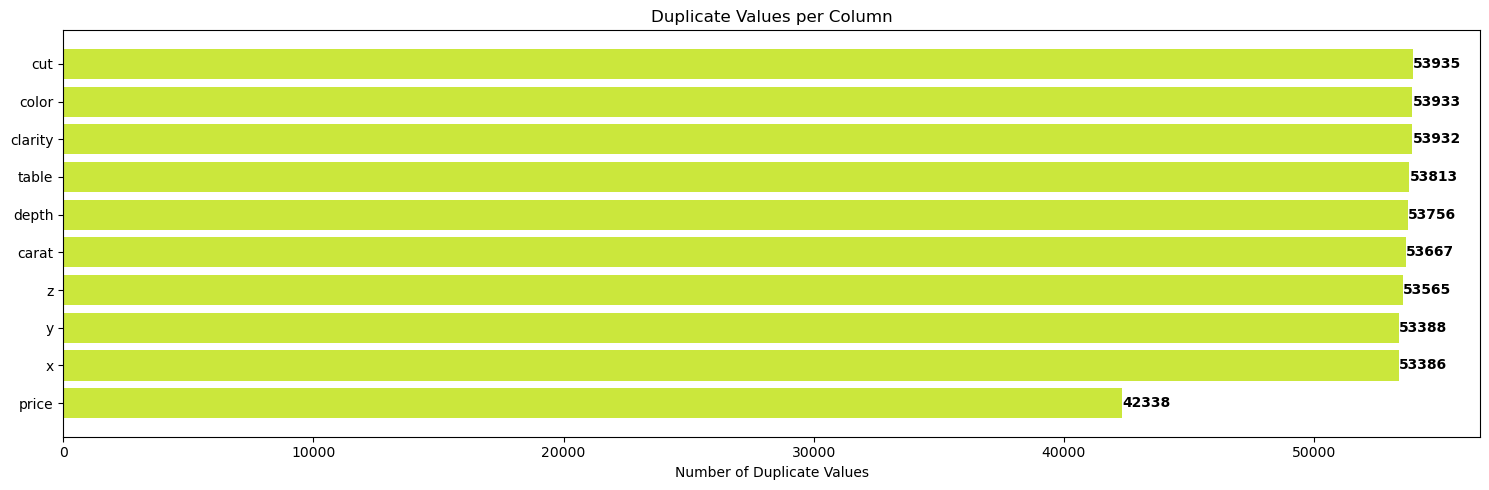

In [9]:
fig,ax = plt.subplots(figsize=(15,5))
ax.barh(duplicate.index,duplicate['Duplicate Count'].values,color="#cbe73c")
ax.set_xlabel("Number of Duplicate Values")
ax.set_title("Duplicate Values per Column")
for i,v in enumerate(duplicate['Duplicate Count'].values):
    if v > 0:
        ax.text(v+0.005,i,str(v),va='center',fontweight='bold')
plt.tight_layout()
plt.show()

## 4.Target Variabel Distribution

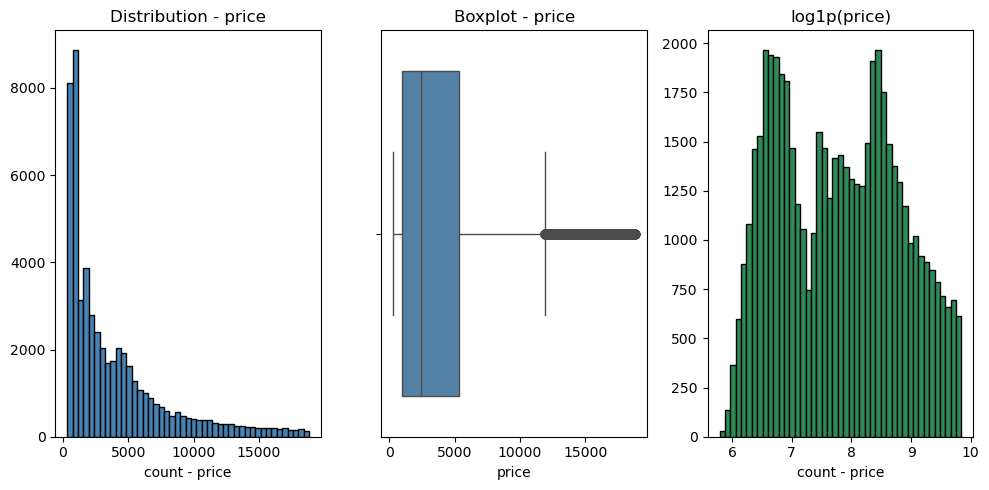

In [10]:
fig,axes = plt.subplots(1,3,figsize=(10,5))
axes[0].hist(df[y_target].dropna(),bins=45,color='steelblue',edgecolor='black')
axes[0].set_title(f'Distribution - {y_target}')
axes[0].set_xlabel(f'count - {y_target}')

sns.boxplot(x=df[y_target].dropna(),ax = axes[1],color='steelblue')
axes[1].set_title(f'Boxplot - {y_target}') 

axes[2].hist(np.log1p(df[y_target].dropna()),bins=45,color='seagreen',edgecolor='black')
axes[2].set_title(f'log1p({y_target})')
axes[2].set_xlabel(f'count - {y_target}')
plt.tight_layout()
plt.show()

In [11]:
describe = df[y_target].describe().round(3) #sudah berbentuk dataframe
y_stats = pd.DataFrame({
    y_target: [round(df[y_target].skew(), 3), round(df[y_target].kurtosis(), 3)]
},index=['Skewness', 'Kurtosis'])
df_stats = pd.concat([describe,y_stats]).T
df_stats

,count,mean,std,min,25%,50%,75%,max,Skewness,Kurtosis
price,53940.0,3932.8,3989.44,326.0,950.0,2401.0,5324.25,18823.0,1.618,2.178


## 5. Univariat Analysis -- Numerical Features

In [12]:
feature_numerik = df.select_dtypes(include=[np.number]).columns.to_list()
ignored_features = [y_target]
feature_numerik = [col for col in feature_numerik if col not in ignored_features]

print(f'Numeric features ({len(feature_numerik)}):')
print(feature_numerik[:30])

Numeric features (6):
['carat', 'depth', 'table', 'x', 'y', 'z']


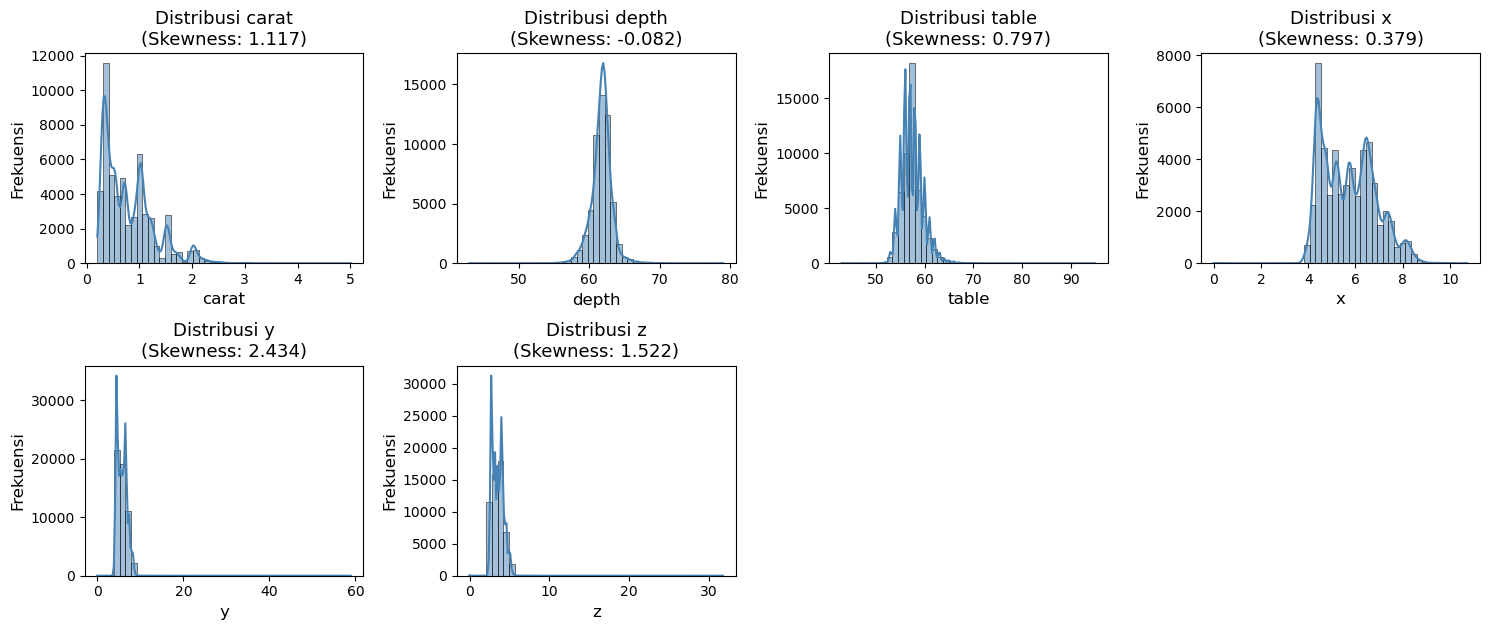

In [13]:
n_show = len(feature_numerik)
n_cols = 4
nrows = math.ceil(n_show/n_cols)

fig,axes = plt.subplots(nrows,n_cols,figsize=(15,3.2*nrows))
axes = axes.flatten()
for i,feature in enumerate(feature_numerik):
    feat_skew = df[feature].skew()
    sns.histplot(df[feature],ax=axes[i],kde=True,color='steelblue',edgecolor='black',bins=45)
    axes[i].set_title( f"Distribusi {feature}\n(Skewness: {feat_skew:.3f})",fontsize=13)
    axes[i].set_xlabel(feature, fontsize=12)
    axes[i].set_ylabel("Frekuensi", fontsize=12)
for j in range(n_show, len(axes)):
    axes[j].axis('off')
plt.tight_layout()
plt.show()

## 6. Univariate Analysis -- Categorical Features

In [14]:
feature_categori = df.select_dtypes(include='object').columns.to_list()
print(f'Numeric features ({len(feature_categori)}):')
print(feature_categori[:30])

Numeric features (3):
['cut', 'color', 'clarity']


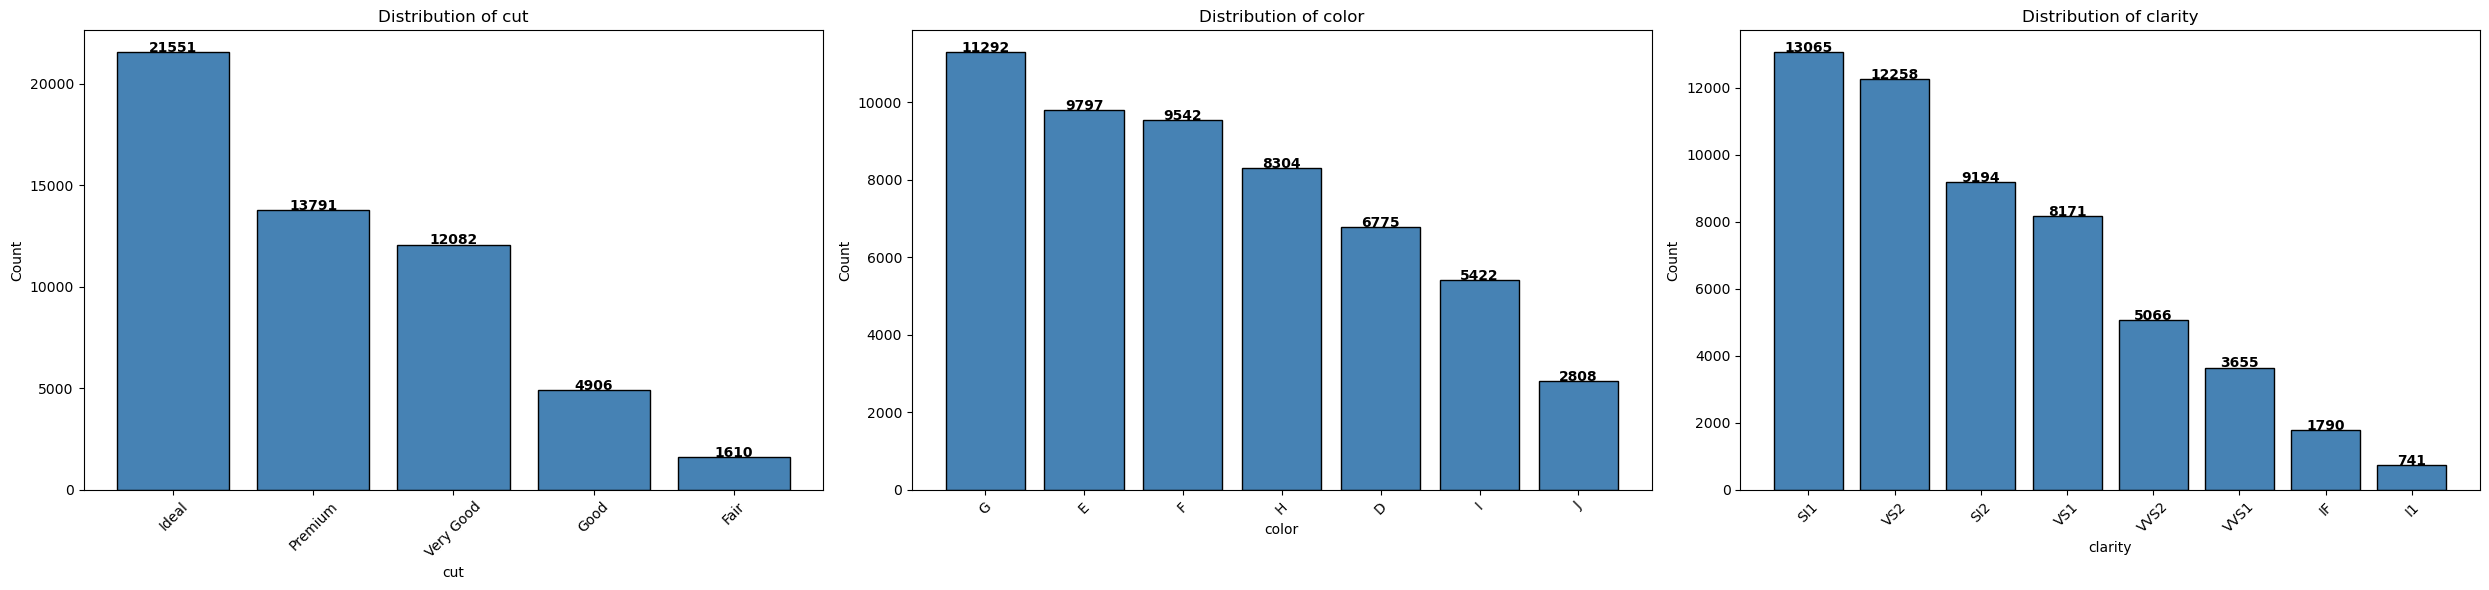

In [15]:
n_show = len(feature_categori)
n_cols = 3
nrows = math.ceil(n_show/n_cols)

fig,axes = plt.subplots(nrows,n_cols,figsize=(25,6*nrows))
axes = axes.flatten()
for i,feature in enumerate(feature_categori):
    counts = df[feature].value_counts()
    axes[i].bar(counts.index.astype(str), counts.values, color='steelblue', edgecolor="black")
    axes[i].set_title(f"Distribution of {feature}")
    axes[i].set_xlabel(feature)
    axes[i].set_ylabel("Count")
    axes[i].tick_params(axis='x', rotation=45)
    for j, v in enumerate(counts.values):
        axes[i].text(j, v + 5, str(v), ha="center", fontweight="bold")
    for j in range(n_show, len(axes)):
        axes[j].axis('off')
plt.tight_layout()
plt.show()

## 7.Bivariate Analysis -- Features Numeric VS Target

In [16]:
feature_numerik = df.select_dtypes(include=[np.number]).columns.to_list()
corrs_all = df[feature_numerik].corr()[y_target].abs().sort_values(ascending=False)
top_features = [x for x in corrs_all.index if x != y_target][:20]
print('Top features by |correlation| with target:')
print(corrs_all[top_features].round(3))

Top features by |correlation| with target:
carat    0.922
x        0.884
y        0.865
z        0.861
table    0.127
depth    0.011
Name: price, dtype: float64


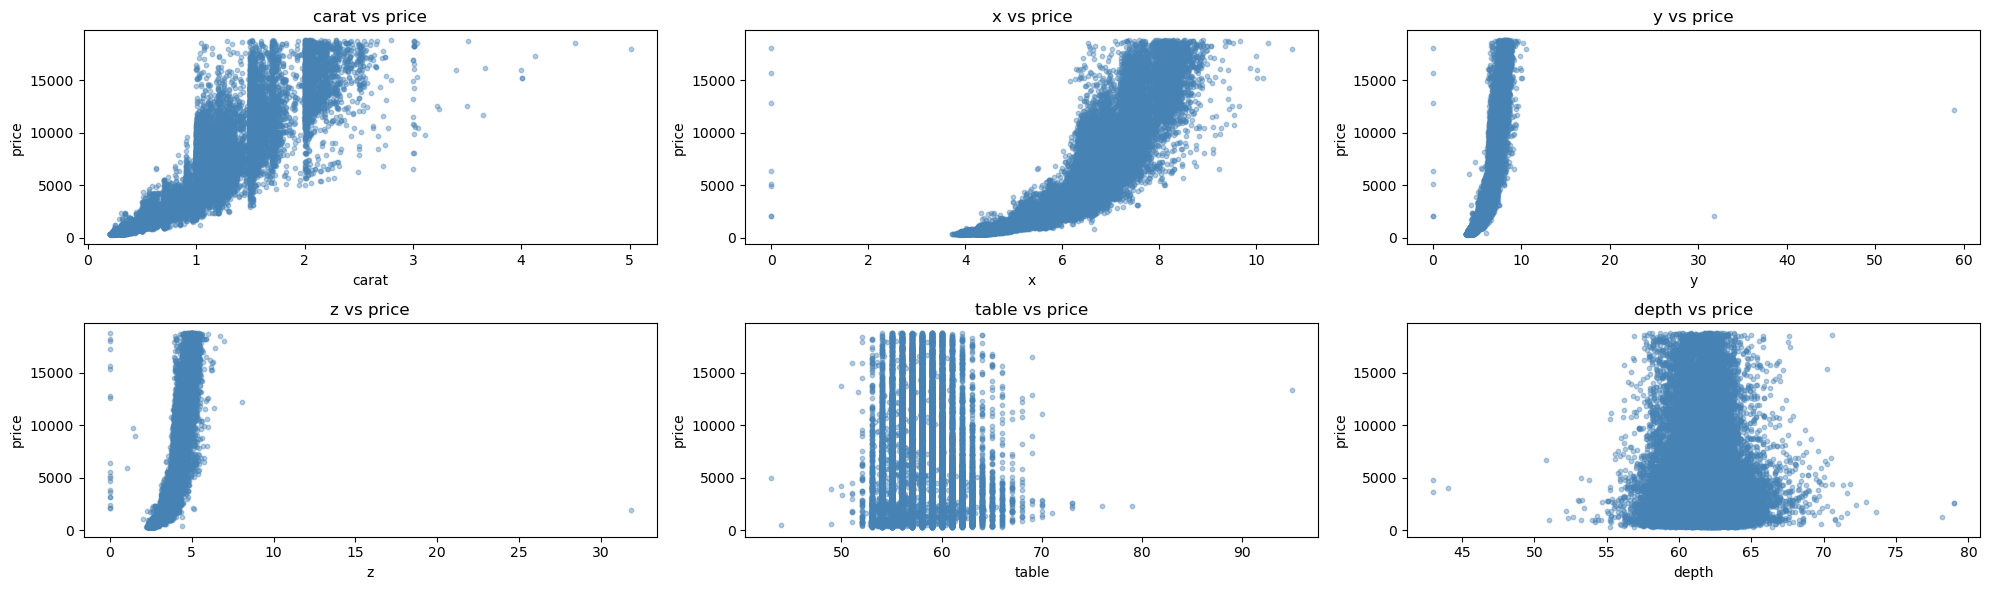

In [17]:
n_show = len(top_features)
n_cols = 3
nrows = math.ceil(n_show/n_cols)

fig,axes = plt.subplots(nrows,n_cols,figsize=(20,3.0*nrows))
axes = axes.flatten()
for i,feature in enumerate(top_features):
    axes[i].scatter(df[feature],df[y_target],alpha=0.4,s=10,color='steelblue')
    axes[i].set_xlabel(feature); axes[i].set_ylabel(f'{y_target}')
    axes[i].set_title(f'{feature} vs {y_target}')
for j in range(n_show, len(axes)):
    axes[j].axis('off')
plt.tight_layout()
plt.show()

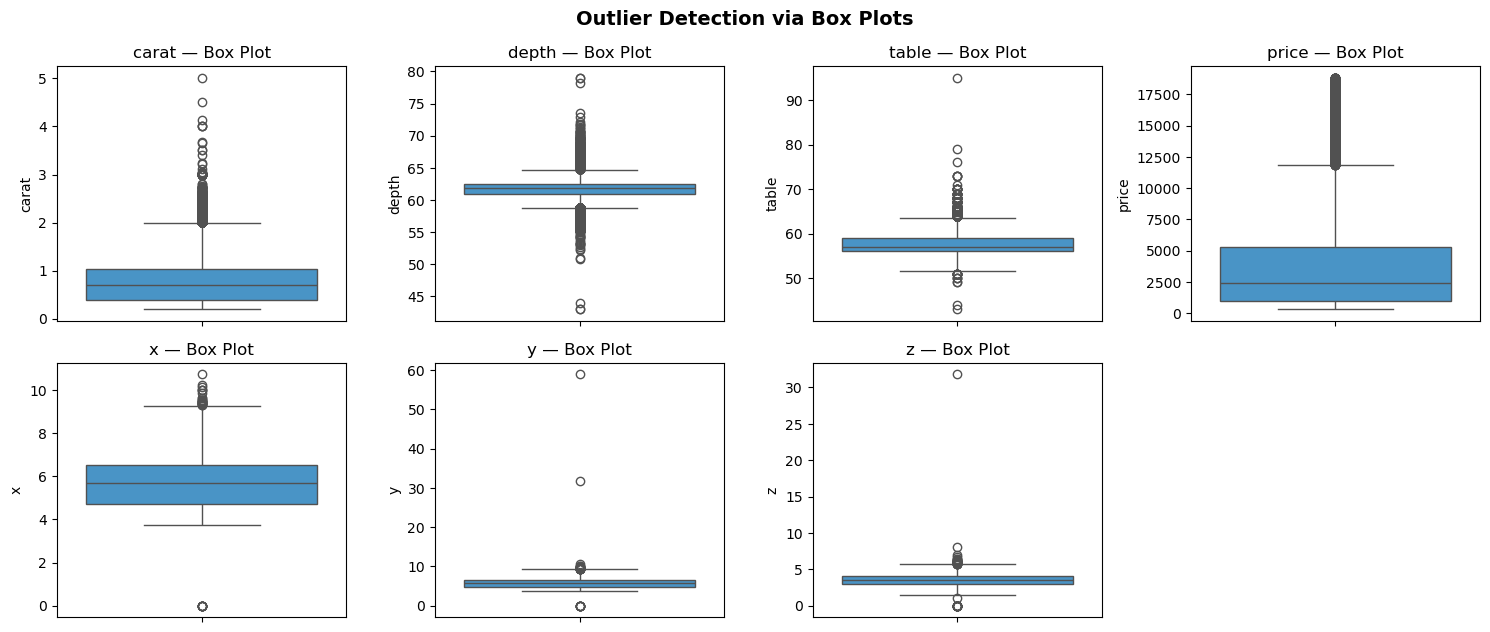

In [24]:
n_show = len(feature_numerik)
n_cols = 4
nrows = math.ceil(n_show/n_cols)

fig,axes = plt.subplots(nrows,n_cols,figsize=(15,3.2*nrows))
axes = axes.flatten()
for i, col in enumerate(feature_numerik):
    sns.boxplot(y=df[col], ax=axes[i], color="#3498db")
    axes[i].set_title(f"{col} — Box Plot")
for j in range(n_show, len(axes)):
        axes[j].axis('off')

plt.suptitle("Outlier Detection via Box Plots", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

## 8. Bivariate Analysis -- Features Categoric VS Target

In [19]:
anova_results = []
for col in feature_categori:
    categories = df[col].dropna().unique()
    groups = [df[df[col] == cat][y_target].dropna() for  cat in categories]

    try:
        f_stats, p_val = stats.f_oneway(*groups)
        conclusion = "Signifikan" if p_val < 0.05 else "Tidak Signifikan"
        anova_results.append({
            'Feature': col,
            'F-Statistic': round(f_stats),
            'P-Value': round(p_val,1),
            'Conclusion': conclusion
        })
    except Exception as e:
        print(f"Gagal melakukan uji ANOVA untuk kolom {col}: {e}")
df_anova = pd.DataFrame(anova_results)
df_anova = df_anova.sort_values(by='F-Statistic',ascending=False).reset_index(drop=True)
df_anova

,Feature,F-Statistic,P-Value,Conclusion
0,color,290,0.0,Signifikan
1,clarity,215,0.0,Signifikan
2,cut,176,0.0,Signifikan


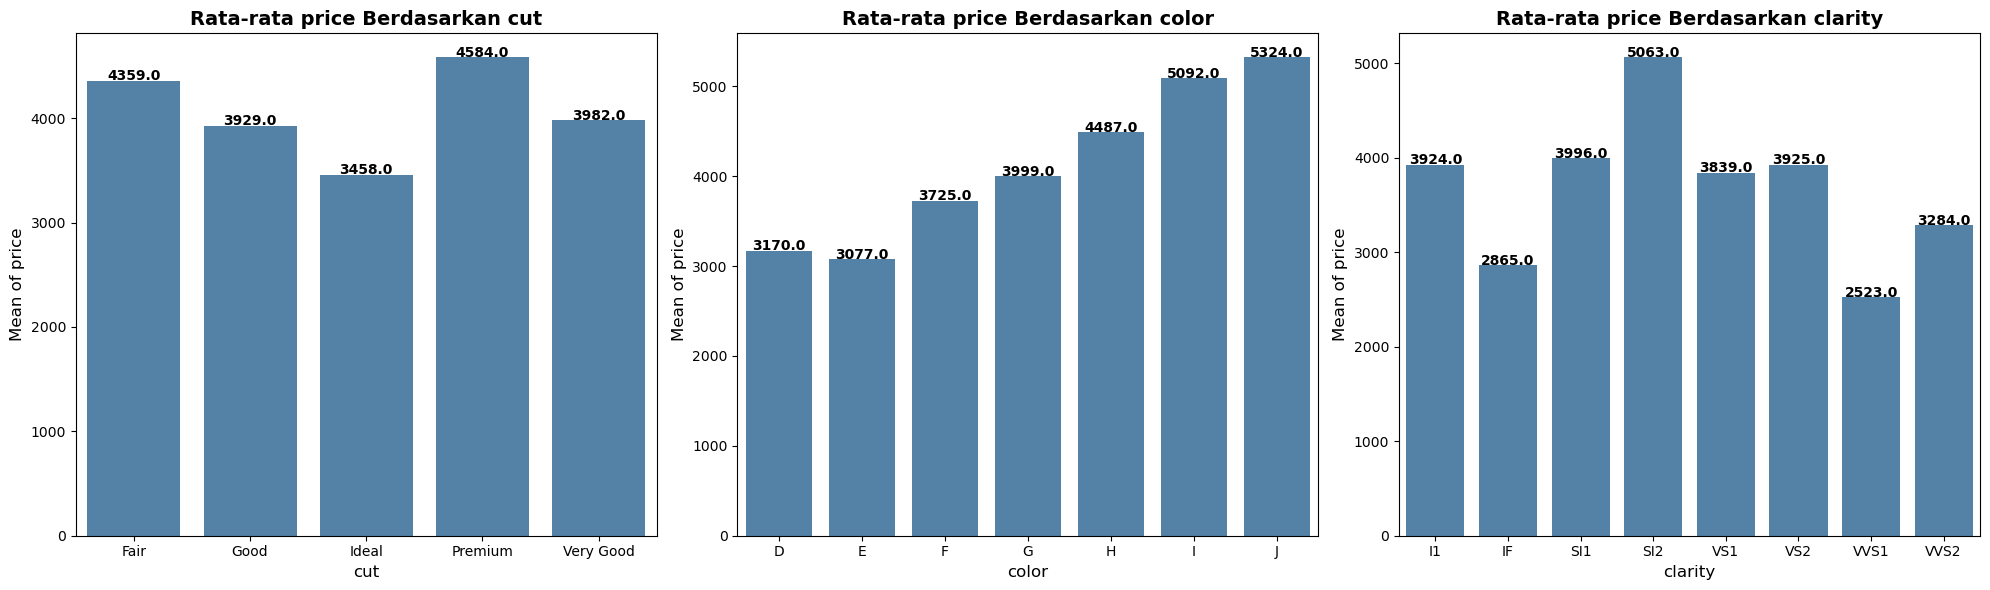

In [20]:
n_show = len(feature_categori)
n_cols = 3
nrows = math.ceil(n_show / n_cols)

fig, axes = plt.subplots(nrows, n_cols, figsize=(20, 6 * nrows))
axes = axes.flatten()

for i, col in enumerate(feature_categori):
    group_mean = df.groupby(col)[y_target].mean().reset_index().round()
    sns.barplot(data=df, x=col, y=y_target, color='steelblue', errorbar=None, ax=axes[i],order=group_mean[col]) 
    axes[i].set_title(f"Rata-rata {y_target} Berdasarkan {col}", fontsize=14, fontweight='bold')
    axes[i].set_xlabel(col, fontsize=12)
    axes[i].set_ylabel(f"Mean of {y_target}", fontsize=12)
    for j, v in enumerate(group_mean[y_target]):
        axes[i].text(j,v+5,str(v), ha="center", fontweight="bold")
for j in range(n_show, len(axes)):
        axes[j].axis('off')
    
plt.tight_layout()
plt.show()

## 9.Multivariat Analysis 

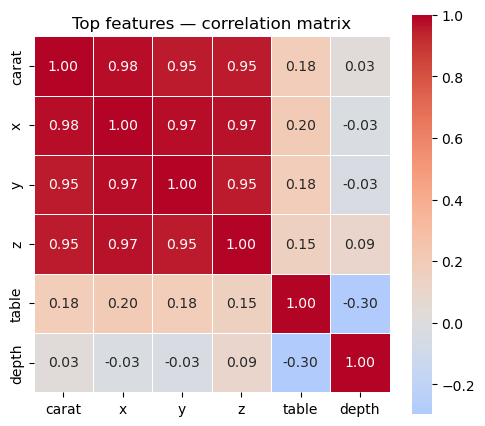

In [21]:
corr_matrix = df[top_features].corr()
plt.figure(figsize=(5,6))
sns.heatmap(corr_matrix,annot=True,fmt='.2f', cmap='coolwarm', center=0, square=True, linewidths=0.5, cbar_kws={'shrink': 0.7})
plt.title('Top features — correlation matrix')
plt.tight_layout()
plt.show()

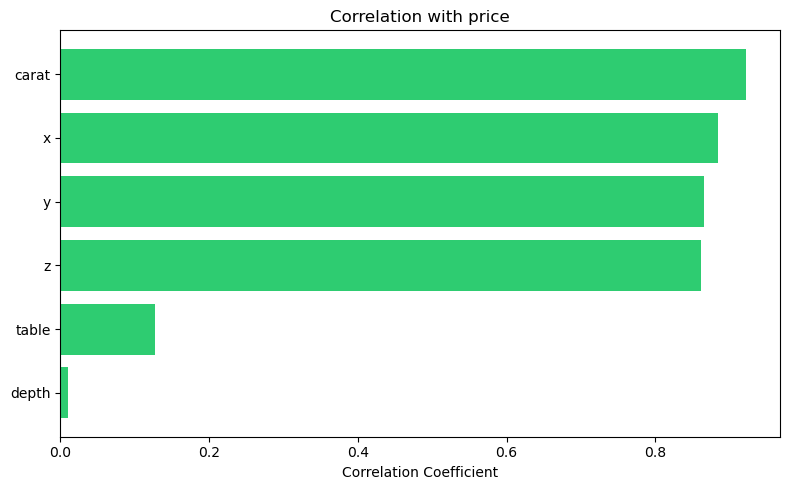

In [22]:
target_corr = df[feature_numerik].corr()[y_target].abs().drop(y_target).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 5))
colors = ["#e74c3c" if v < 0 else "#2ecc71" for v in target_corr.values]
ax.barh(target_corr.index, target_corr.values, color=colors)
ax.set_title(f"Correlation with {y_target}")
ax.set_xlabel("Correlation Coefficient")
ax.axvline(x=0, color="black", linewidth=0.5)
plt.tight_layout()
plt.show()

## 10.Summary of EDA Findings

In [23]:
summary = pd.DataFrame({
    'Metric': ['Total samples', 'Total features', 'Target mean', 'Target median',
               'Target stddev', 'Target min', 'Target max', 'Target skewness',
               'Top correlated feature', 'Top correlation value'],
    'Value': [
        len(df), df.shape[1] - 1,
        round(df[y_target].mean(), 2),
        round(df[y_target].median(), 2),
        round(df[y_target].std(), 2),
        round(df[y_target].min(), 2),
        round(df[y_target].max(), 2),
        round(df[y_target].skew(), 3),
        top_features[0],
        round(corrs_all[top_features[0]], 3),
    ],
})
summary

,Metric,Value
0,Total samples,53940
1,Total features,9
2,Target mean,3932.8
3,Target median,2401.0
4,Target stddev,3989.44
5,Target min,326
6,Target max,18823
7,Target skewness,1.618
8,Top correlated feature,carat
9,Top correlation value,0.922
